In [ ]:
!pip install torch-geometric -q

import math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data, DataLoader
from nn_conv import NNConv_old

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.6 MB/s eta 0:00:00


device(type='cuda')

In [ ]:


CSV_PATH = "/content/new_master_panel_residual_load.csv"

NODE_COL = "node_id"
TIME_COL = "datetime"
LAT_COL = "lat"
LON_COL = "lon"


PER_NODE_NORM_COLUMNS = [
    "residual_load",
]

FEATURE_COLUMNS = [

    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",

    "is_weekend",
    "is_holiday",
    "daylight_hours",


    "temperature",
    "heating_degree",
    "cooling_degree",


    "solar_ghi",
    "wind_100m",


]

# Prediction horizon: Δt = 1 → target = normalized residual_load(t)
ORIGINAL_TARGET_COL = "residual_load"
TARGET_COL = "target_residual_load_norm"

#graph construction
GRAPH_METHOD = "hybrid"      # "knn" or "radius"
K_NEIGHBORS = 10
RADIUS_KM = 350.0  #ignored when method is knn

#training hyperparameters adapted manually after stage 1 optuna run below
BASE_CONFIG = {
    "hidden_width": 96,
    "kernel_width": 192,
    "depth": 4,
    "lr": 0.002000831450926973,
    "weight_decay": 1.0107143352552824e-07,
    "batch_size": 8,
    "num_epochs": 80,
}


In [ ]:
import numpy as np
import torch

def build_graph_from_coords(
    node_df,
    method="hybrid",          # "radius", "knn", or "hybrid"
    k_neighbors=6,
    radius_km=500.0,
    min_k=3,
    max_k=12,
    rbf_sigmas=(0.05, 0.10, 0.20, 0.40),
):
    """
    Returns:
      node_index_map: dict node_id -> contiguous index
      pos_t: (N,2) normalized [lat_norm, lon_norm]
      edge_index: (2,E) long tensor
      edge_attr: (E, 3 + len(rbf_sigmas)) float tensor: [dx, dy, dist_norm, rbf...]
      lat_norm, lon_norm: arrays (N,)
    """
    node_ids = node_df.index.to_list()
    N = len(node_ids)
    node_index_map = {nid: i for i, nid in enumerate(node_ids)}

    lat = node_df["lat"].values.astype(float)
    lon = node_df["lon"].values.astype(float)


    lat_norm = (lat - lat.min()) / (lat.max() - lat.min() + 1e-9)
    lon_norm = (lon - lon.min()) / (lon.max() - lon.min() + 1e-9)
    pos = np.stack([lat_norm, lon_norm], axis=1)


    def haversine_distance(lat1, lon1, lat2, lon2):
        R = 6371.0
        lat1 = np.radians(lat1); lon1 = np.radians(lon1)
        lat2 = np.radians(lat2); lon2 = np.radians(lon2)
        dlat = lat2 - lat1; dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        return 2 * R * np.arcsin(np.sqrt(a))

    lat_mesh1, lat_mesh2 = np.meshgrid(lat, lat, indexing="ij")
    lon_mesh1, lon_mesh2 = np.meshgrid(lon, lon, indexing="ij")
    dist_km = haversine_distance(lat_mesh1, lon_mesh1, lat_mesh2, lon_mesh2)

    rows, cols = [], []

    def add_undirected_edges(i, neigh_idx):

        for j in neigh_idx:
            rows.append(i); cols.append(j)
            rows.append(j); cols.append(i)

    if method == "knn":
        for i in range(N):
            d = dist_km[i].copy()
            d[i] = np.inf
            neigh_idx = np.argsort(d)[:k_neighbors]
            add_undirected_edges(i, neigh_idx)

    elif method == "radius":
        for i in range(N):
            d = dist_km[i].copy()
            d[i] = np.inf
            within = np.where(d <= radius_km)[0]


            if within.size > max_k:
                within = within[np.argsort(d[within])[:max_k]]

            if within.size < min_k:
                within = np.argsort(d)[:max(min_k, k_neighbors)]

            add_undirected_edges(i, within)

    elif method == "hybrid":
        for i in range(N):
            d = dist_km[i].copy()
            d[i] = np.inf

            within = np.where(d <= radius_km)[0]


            if within.size > max_k:
                within = within[np.argsort(d[within])[:max_k]]


            if within.size < min_k:
                need = max(min_k, k_neighbors)
                within = np.argsort(d)[:need]

            add_undirected_edges(i, within)

    else:
        raise ValueError(f"Unknown method={method}. Use 'knn', 'radius', or 'hybrid'.")

    edge_index = torch.tensor([rows, cols], dtype=torch.long)


    pos_t = torch.tensor(pos, dtype=torch.float32)
    row, col = edge_index[0], edge_index[1]
    rel = pos_t[col] - pos_t[row]
    dx = rel[:, 0:1]
    dy = rel[:, 1:2]

    dist_vals = dist_km[row.numpy(), col.numpy()]
    dist_norm = dist_vals / (dist_km.max() + 1e-9)
    dist_norm = torch.tensor(dist_norm, dtype=torch.float32).unsqueeze(-1)  # (E,1)


    # rbf_k = exp(-(d^2)/(2*sigma^2))
    rbf_feats = []
    for s in rbf_sigmas:
        s = float(s)
        rbf_feats.append(torch.exp(-(dist_norm ** 2) / (2.0 * (s ** 2) + 1e-12)))
    rbf = torch.cat(rbf_feats, dim=-1) if len(rbf_feats) > 0 else None

    edge_attr = torch.cat([dx, dy, dist_norm, rbf], dim=-1) if rbf is not None else torch.cat([dx, dy, dist_norm], dim=-1)

    return node_index_map, pos_t, edge_index, edge_attr, lat_norm, lon_norm


In [ ]:
def load_and_preprocess_panel(csv_path):
    df = pd.read_csv(csv_path)
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])
    df = df.sort_values([NODE_COL, TIME_COL])


    WEATHER_COLUMNS = ["solar_ghi", "wind_100m"]
    for wcol in WEATHER_COLUMNS:
        if wcol in df.columns:
            df[wcol] = df[wcol].fillna(0.0)


    node_df = (
        df[[NODE_COL, LAT_COL, LON_COL]]
        .drop_duplicates(NODE_COL)
        .set_index(NODE_COL)
        .sort_index()
    )


    (node_index_map, pos_tensor, edge_index, edge_attr,
     lat_norm, lon_norm) = build_graph_from_coords(
        node_df,
        method=GRAPH_METHOD,
        k_neighbors=K_NEIGHBORS,
        radius_km=RADIUS_KM,
    )

    node_df["lat_norm"] = lat_norm
    node_df["lon_norm"] = lon_norm


    df = df.merge(
        node_df[["lat_norm", "lon_norm"]].reset_index(),
        on=NODE_COL,
        how="left",
    )


    for cname in ["lat_norm", "lon_norm"]:
        if cname not in FEATURE_COLUMNS:
            FEATURE_COLUMNS.append(cname)


    return df, node_df, node_index_map, pos_tensor, edge_index, edge_attr



def split_panel_by_time(df, train_frac=0.7, val_frac=0.15):
    """
    Split df into train/val/test based on label_time automatically.
    """
    times = np.sort(df["label_time"].unique())
    n = len(times)

    if n < 3:
        raise ValueError(f"Not enough time steps ({n}) for train/val/test split.")

    train_end_idx = int(n * train_frac)
    val_end_idx = int(n * (train_frac + val_frac))

    train_end_idx = max(1, min(train_end_idx, n - 2))
    val_end_idx = max(train_end_idx + 1, min(val_end_idx, n - 1))

    train_end_time = times[train_end_idx - 1]
    val_end_time = times[val_end_idx - 1]

    df_train = df[df["label_time"] <= train_end_time].copy()
    df_val   = df[(df["label_time"] > train_end_time) & (df["label_time"] <= val_end_time)].copy()
    df_test  = df[df["label_time"] > val_end_time].copy()

    print("Time range:", times[0], "→", times[-1])
    print("Train up to:", train_end_time)
    print("Val   up to:", val_end_time)
    print("Rows train/val/test:", len(df_train), len(df_val), len(df_test))

    return df_train, df_val, df_test


In [ ]:
#panel dataframe into list of PyTorch Geometric graphs (one graph per timestep)
#sequence of graphs
def build_dataset_from_panel(df_split, node_index_map, edge_index, edge_attr):
    data_list = []

    df_split["node_idx"] = df_split[NODE_COL].map(node_index_map)
    unique_times = df_split[TIME_COL].sort_values().unique()

    num_nodes = len(node_index_map)
    print("Nodes:", num_nodes, "Timesteps:", len(unique_times))

    for t in unique_times:
        df_t = df_split[df_split[TIME_COL] == t].sort_values("node_idx")
        if len(df_t) != num_nodes:
            continue

        x = torch.tensor(df_t[FEATURE_COLUMNS].values, dtype=torch.float32)
        y = torch.tensor(df_t[TARGET_COL].values, dtype=torch.float32)

        data = Data(x=x, y=y, edge_index=edge_index, edge_attr=edge_attr)
        data_list.append(data)

    return data_list


In [ ]:
class DenseNet(nn.Module):
    def __init__(self, layers, activation):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(layers[i], layers[i+1])
            for i in range(len(layers)-1)
        ])
        self.activation = activation()

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        return self.layers[-1](x)


class KernelNN(nn.Module):
    """
    Graph Neural Operator:
      x_t → fc1 → NNConv(kernel(edge_attr))×depth → fc2 → y_t
    """
    def __init__(self, in_width, edge_feat_dim, width=96, ker_width=96, depth=5, out_width=1):
        super().__init__()
        self.depth = depth

        self.fc1 = nn.Linear(in_width, width)

        kernel = DenseNet([edge_feat_dim, ker_width, ker_width, width*width], nn.ReLU)
        self.conv1 = NNConv_old(width, width, kernel, aggr="mean")

        self.fc2 = nn.Linear(width, out_width)

    def forward(self, data):
        x = self.fc1(data.x)
        for _ in range(self.depth):
            x = F.relu(self.conv1(x, data.edge_index, data.edge_attr))
        return self.fc2(x).squeeze(-1)


In [ ]:
def evaluate(model, loader):
    model.eval()
    total_mse = 0
    total_nodes = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            mse = F.mse_loss(out, batch.y, reduction="sum")
            total_mse += mse.item()
            total_nodes += batch.y.numel()
    return total_mse / total_nodes


def train_one_experiment(config=None):
    if config is None:
        config = BASE_CONFIG


    df, node_df, node_index_map, pos, edge_index, edge_attr = load_and_preprocess_panel(CSV_PATH)



    def week_mask(df_local, start, end):
        return (df_local[TIME_COL] >= start) & (df_local[TIME_COL] < end)

    winter_mask  = week_mask(df, "2025-01-10", "2025-01-17")
    spring_mask  = week_mask(df, "2025-04-10", "2025-04-17")
    summer_mask  = week_mask(df, "2025-07-10", "2025-07-17")
    autumn_mask  = week_mask(df, "2025-10-10", "2025-10-17")

    scenario_mask = winter_mask | spring_mask | summer_mask | autumn_mask

    df_scenarios = df[scenario_mask].copy()
    df_rest      = df[~scenario_mask].copy()

    print("Scenario rows:", len(df_scenarios), "| Train/Val/Test rows:", len(df_rest))



    unique_times = df_rest[TIME_COL].sort_values().unique()


    rng = np.random.RandomState(0)
    perm = rng.permutation(len(unique_times))
    unique_times = unique_times[perm]

    n = len(unique_times)
    n_train = int(n * 0.70)
    n_val   = int(n * 0.15)
    n_train = max(1, n_train)
    n_val   = max(1, n_val)

    train_times = unique_times[:n_train]
    val_times   = unique_times[n_train:n_train + n_val]
    test_times  = unique_times[n_train + n_val:]

    df_train = df_rest[df_rest[TIME_COL].isin(train_times)].copy()
    df_val   = df_rest[df_rest[TIME_COL].isin(val_times)].copy()
    df_test  = df_rest[df_rest[TIME_COL].isin(test_times)].copy()

    print("Random time split (excluding scenario weeks):")
    print("  Train timesteps:", len(np.unique(df_train[TIME_COL])))
    print("  Val timesteps:  ", len(np.unique(df_val[TIME_COL])))
    print("  Test timesteps: ", len(np.unique(df_test[TIME_COL])))
    print("  Rows train/val/test:", len(df_train), len(df_val), len(df_test))



    stats = (
        df_train.groupby(NODE_COL)[ORIGINAL_TARGET_COL]
        .agg(["mean", "std"])
        .rename(columns={"mean": "rl_mean", "std": "rl_std"})
    )
    stats["rl_std"].replace(0, 1.0, inplace=True)


    def apply_norm(split):
        split = split.merge(stats, left_on=NODE_COL, right_index=True, how="left")


        split["residual_load_norm"] = (
            (split[ORIGINAL_TARGET_COL] - split["rl_mean"]) / split["rl_std"]
        )


        split[TARGET_COL] = split["residual_load_norm"]


        cols_required = FEATURE_COLUMNS + [TARGET_COL]
        before = len(split)
        split = split.dropna(subset=cols_required)
        after = len(split)
        print(f"Dropped {before - after} rows in this split due to NaNs.")
        return split


    df_train = apply_norm(df_train)
    df_val   = apply_norm(df_val)
    df_test  = apply_norm(df_test)


    train_data = build_dataset_from_panel(df_train, node_index_map, edge_index, edge_attr)
    val_data   = build_dataset_from_panel(df_val,   node_index_map, edge_index, edge_attr)
    test_data  = build_dataset_from_panel(df_test,  node_index_map, edge_index, edge_attr)

    train_loader = DataLoader(train_data, batch_size=config["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_data,   batch_size=config["batch_size"], shuffle=False)
    test_loader  = DataLoader(test_data,  batch_size=config["batch_size"], shuffle=False)

    in_width = len(FEATURE_COLUMNS)
    edge_feat_dim = edge_attr.size(-1)

    model = KernelNN(
        in_width=in_width,
        edge_feat_dim=edge_feat_dim,
        width=config["hidden_width"],
        ker_width=config["kernel_width"],
        depth=config["depth"],
        out_width=1,
    ).to(device)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    best_val = float("inf")
    best_state = None


    train_losses = []
    val_losses = []

    for ep in range(config["num_epochs"]):
        model.train()
        total_mse = 0.0
        total_nodes = 0

        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            out = model(batch)
            loss = F.mse_loss(out, batch.y, reduction="mean")
            loss.backward()
            opt.step()

            total_mse += loss.item() * batch.y.numel()
            total_nodes += batch.y.numel()

        train_mse = total_mse / total_nodes
        val_mse = evaluate(model, val_loader)

        train_losses.append(train_mse)
        val_losses.append(val_mse)

        if ep % 5 == 0 or ep == config["num_epochs"] - 1:
            print(f"Epoch {ep:03d} | train MSE {train_mse:.4e} | val MSE {val_mse:.4e}")

        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    test_mse = evaluate(model, test_loader)

    print(f"Best val MSE = {best_val:.4e}")
    print(f"Test MSE     = {test_mse:.4e}")


    return best_val, test_mse, model, train_losses, val_losses, test_loader, test_data


In [ ]:
val_mse, test_mse, model, train_losses, val_losses, test_loader, test_data = train_one_experiment()



Scenario rows: 13440 | Train/Val/Test rows: 132480
Random time split (excluding scenario weeks):
  Train timesteps: 4636
  Val timesteps:   993
  Test timesteps:  995
  Rows train/val/test: 92720 19860 19900
Dropped 11 rows in this split due to NaNs.
Dropped 0 rows in this split due to NaNs.
Dropped 0 rows in this split due to NaNs.
Nodes: 20 Timesteps: 4636


/tmp/ipython-input-51247906.py:78: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stats["rl_std"].replace(0, 1.0, inplace=True)  # avoid division by zero


Nodes: 20 Timesteps: 993
Nodes: 20 Timesteps: 995


/tmp/ipython-input-51247906.py:110: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=config["batch_size"], shuffle=True)
/tmp/ipython-input-51247906.py:111: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_data,   batch_size=config["batch_size"], shuffle=False)
/tmp/ipython-input-51247906.py:112: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_data,  batch_size=config["batch_size"], shuffle=False)


Epoch 000 | train MSE 2.0525e+00 | val MSE 5.8534e-01
Epoch 005 | train MSE 2.9476e-01 | val MSE 2.6102e-01
Epoch 010 | train MSE 2.1219e-01 | val MSE 2.1076e-01
Epoch 015 | train MSE 1.6796e-01 | val MSE 1.4888e-01
Epoch 020 | train MSE 1.4018e-01 | val MSE 1.3935e-01
Epoch 025 | train MSE 1.2542e-01 | val MSE 1.3008e-01
Epoch 030 | train MSE 1.1169e-01 | val MSE 1.2186e-01
Epoch 035 | train MSE 9.8864e-02 | val MSE 1.0564e-01
Epoch 040 | train MSE 9.0894e-02 | val MSE 9.9579e-02
Epoch 045 | train MSE 8.3660e-02 | val MSE 1.0601e-01
Epoch 050 | train MSE 7.6462e-02 | val MSE 8.7021e-02
Epoch 055 | train MSE 6.5983e-02 | val MSE 7.8468e-02
Epoch 060 | train MSE 6.6161e-02 | val MSE 7.6507e-02
Epoch 065 | train MSE 5.8526e-02 | val MSE 7.7685e-02
Epoch 070 | train MSE 5.4255e-02 | val MSE 6.6453e-02
Epoch 075 | train MSE 5.0199e-02 | val MSE 7.6990e-02
Epoch 079 | train MSE 4.5848e-02 | val MSE 7.3778e-02
Best val MSE = 5.9553e-02
Test MSE     = 6.2874e-02


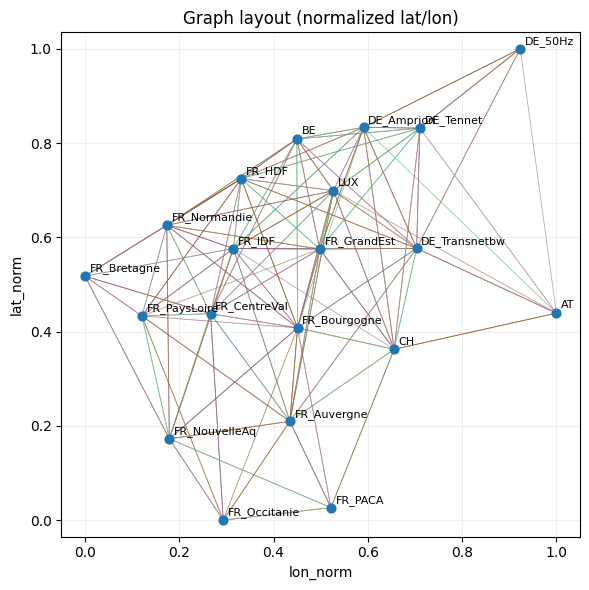

In [ ]:
# --- Build graph once and visualize its spatial structure ---

import matplotlib.pyplot as plt

# Re-use your existing loader to get node positions + edges
df_raw, node_df, node_index_map, pos, edge_index, edge_attr = load_and_preprocess_panel(CSV_PATH)

def plot_graph_layout(node_df, pos, edge_index, title="Graph layout (normalized lat/lon)"):
    """
    Simple 2D plot of your graph:
    - nodes placed by normalized lat/lon
    - edges drawn as straight lines
    - node_id labels
    """
    pos_np = pos.cpu().numpy()
    lat = pos_np[:, 0]
    lon = pos_np[:, 1]

    row, col = edge_index

    plt.figure(figsize=(6, 6))


    for r, c in zip(row.tolist(), col.tolist()):
        plt.plot(
            [lon[r], lon[c]],
            [lat[r], lat[c]],
            linewidth=0.6,
            alpha=0.4,
        )


    plt.scatter(lon, lat, s=40, zorder=3)

    for i, node_id in enumerate(node_df.index):
        plt.text(
            lon[i] + 0.01,
            lat[i] + 0.01,
            str(node_id),
            fontsize=8,
        )

    plt.xlabel("lon_norm")
    plt.ylabel("lat_norm")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# Call once to see the graph
plot_graph_layout(node_df, pos, edge_index)


In [ ]:
#recreate df_scenarios and stats


df_raw, node_df, node_index_map, pos, edge_index, edge_attr = load_and_preprocess_panel(CSV_PATH)

def week_mask(df, start, end):
    return (df[TIME_COL] >= start) & (df[TIME_COL] < end)

winter_mask  = week_mask(df_raw, "2025-01-10", "2025-01-17")
spring_mask  = week_mask(df_raw, "2025-04-10", "2025-04-17")
summer_mask  = week_mask(df_raw, "2025-07-10", "2025-07-17")
autumn_mask  = week_mask(df_raw, "2025-10-10", "2025-10-17")

scenario_mask = winter_mask | spring_mask | summer_mask | autumn_mask
df_scenarios = df_raw[scenario_mask].copy()


df_rest = df_raw[~scenario_mask].copy()

stats = (
    df_rest.groupby(NODE_COL)[ORIGINAL_TARGET_COL]
    .agg(["mean", "std"])
    .rename(columns={"mean": "rl_mean", "std": "rl_std"})
)
stats["rl_std"].replace(0, 1.0, inplace=True)

print("df_scenarios rows:", len(df_scenarios))
print("stats nodes:", len(stats))


df_scenarios rows: 13440
stats nodes: 20


/tmp/ipython-input-671740057.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stats["rl_std"].replace(0, 1.0, inplace=True)


In [ ]:
df_scenarios = df_scenarios.copy()

df_scenarios = df_scenarios.merge(stats, left_on=NODE_COL, right_index=True)

df_scenarios["residual_load_norm"] = (
    (df_scenarios[ORIGINAL_TARGET_COL] - df_scenarios["rl_mean"]) / df_scenarios["rl_std"]
)
df_scenarios[TARGET_COL] = df_scenarios["residual_load_norm"]

df_scenarios = df_scenarios.dropna(subset=FEATURE_COLUMNS + [TARGET_COL])

scenario_data = build_dataset_from_panel(
    df_scenarios, node_index_map, edge_index, edge_attr
)


Nodes: 20 Timesteps: 672


In [ ]:
#plot training and loss curves

import matplotlib.pyplot as plt
import numpy as np

def plot_loss_curves(train_losses, val_losses):
    epochs = np.arange(len(train_losses))

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, train_losses, label="Train MSE")
    plt.plot(epochs, val_losses, label="Val MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


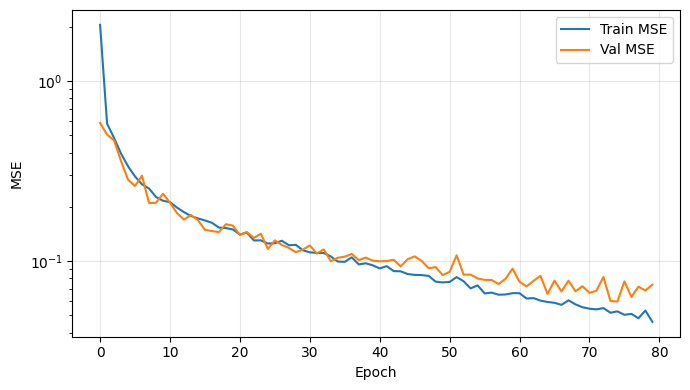

Scenario timesteps: 672 | Num nodes: 20


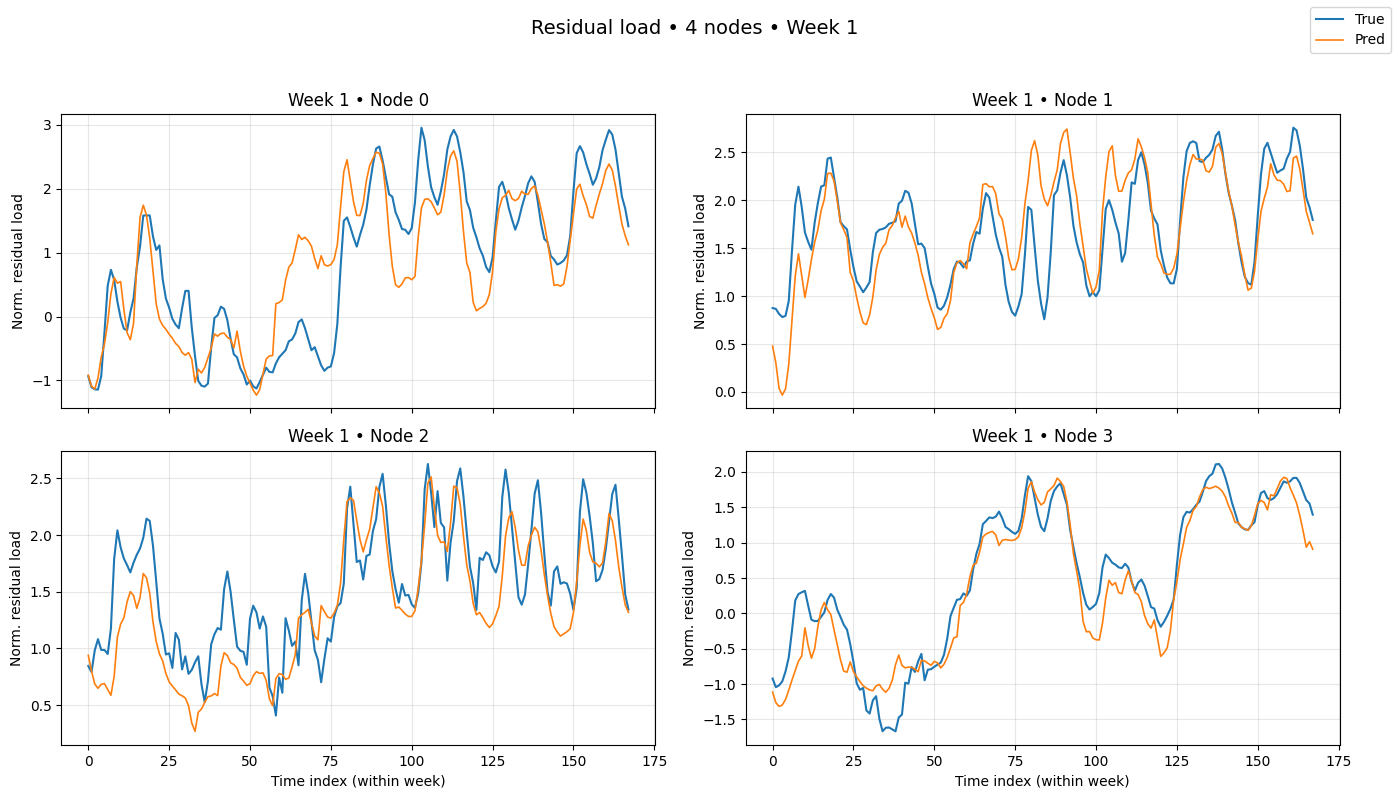

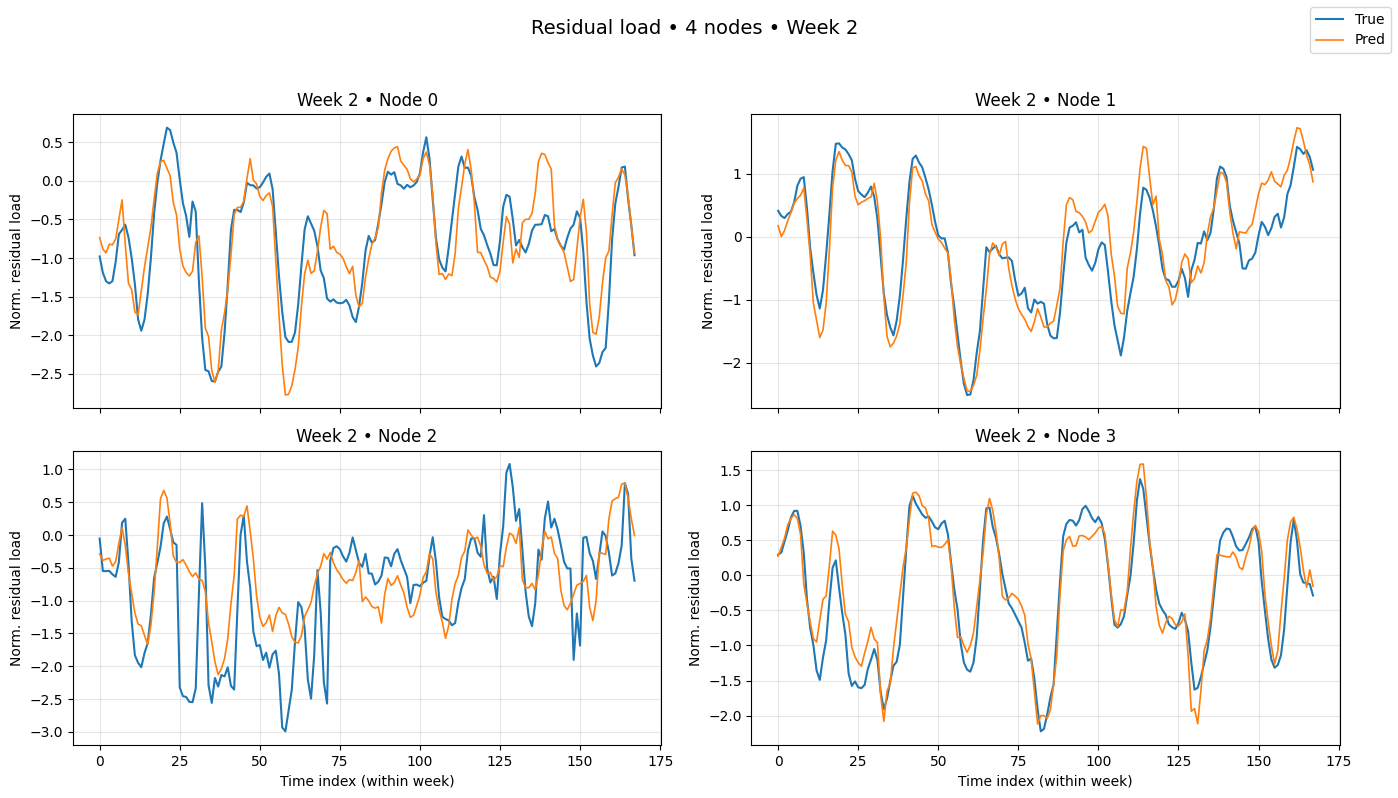

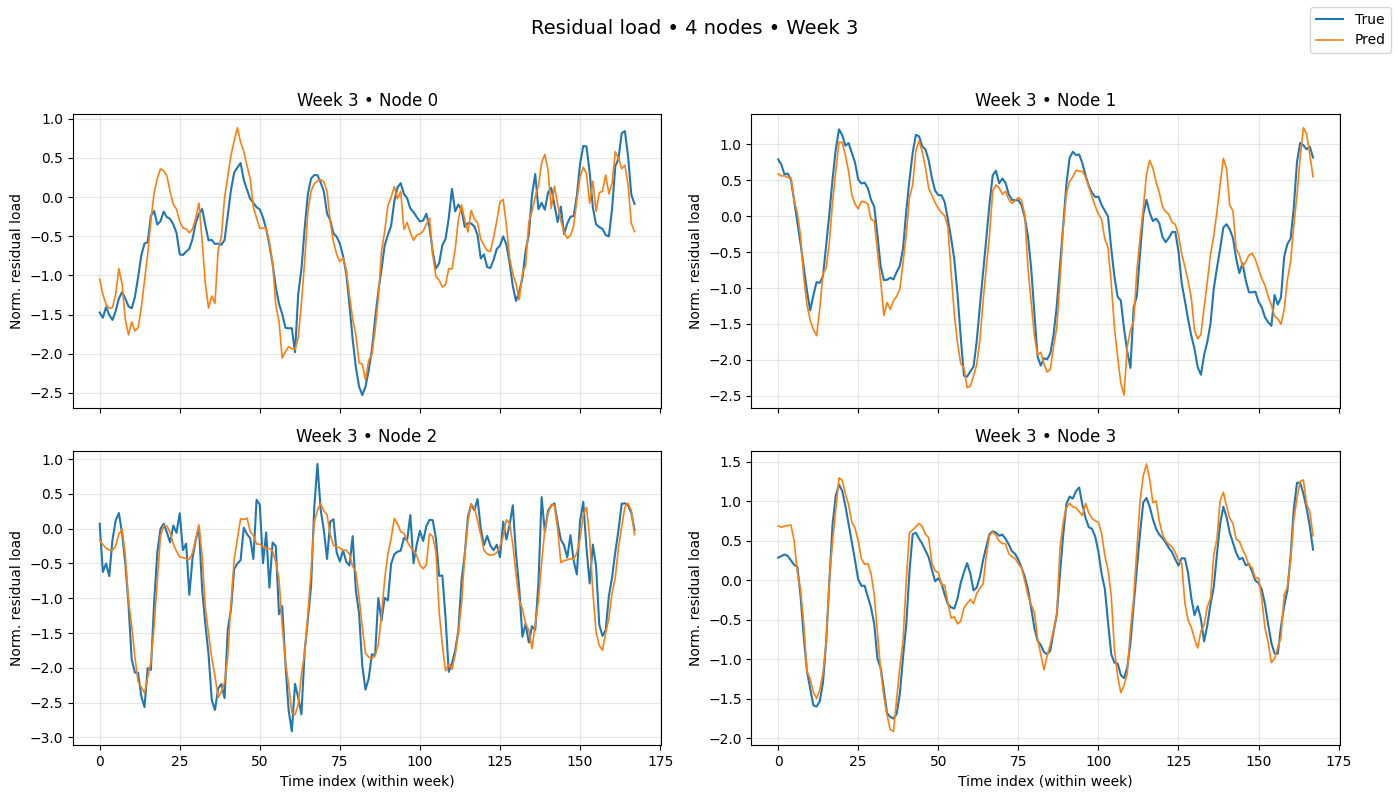

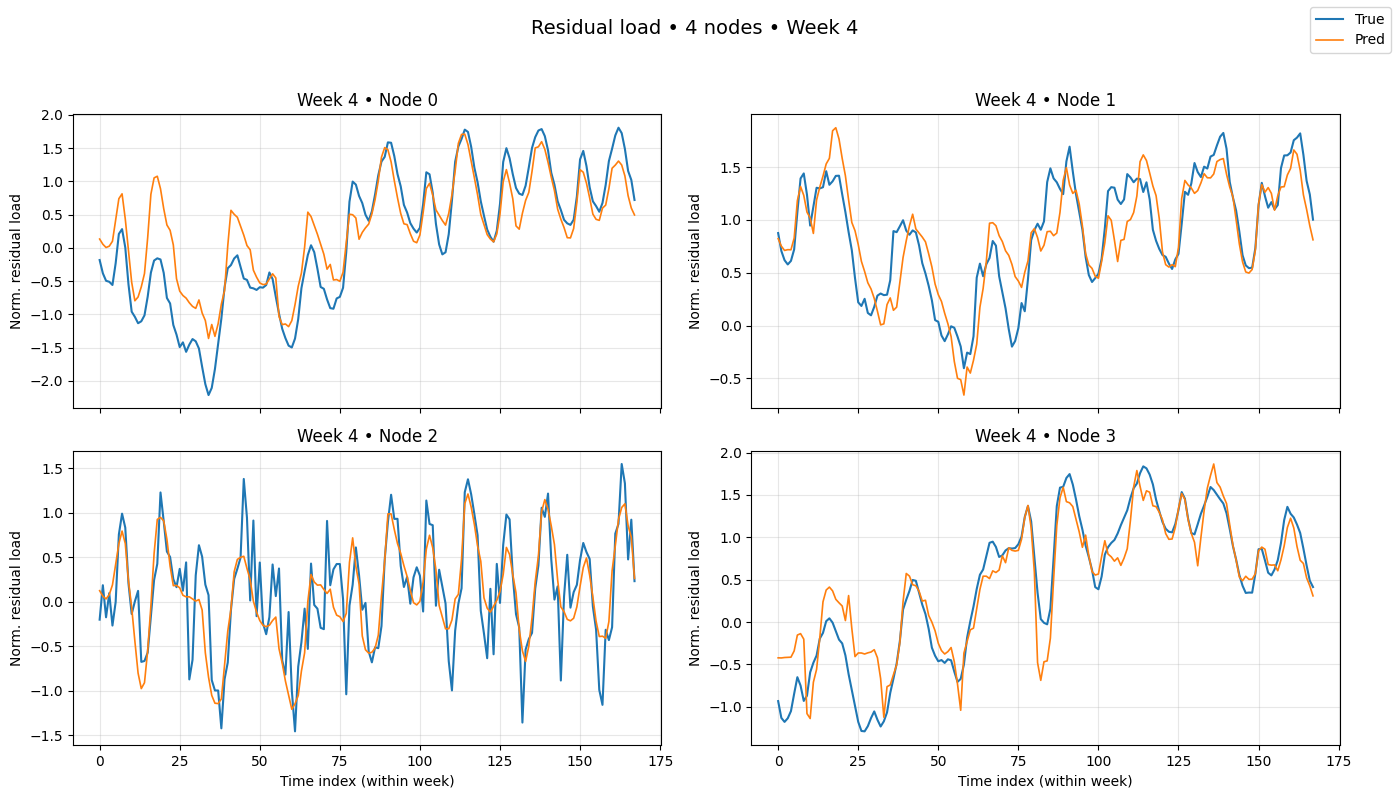

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Loss curves
plot_loss_curves(train_losses, val_losses)

# Predictions on the 4 unseen weeks
# Assumes: model, device, scenario_data already defined

def collect_predictions_2d(model, dataset):
    model.eval()
    preds_list = []
    trues_list = []
    with torch.no_grad():
        for data in dataset:         # one graph = one timestep
            data = data.to(device)
            out = model(data)        # shape (num_nodes,)
            preds_list.append(out.cpu().numpy())
            trues_list.append(data.y.cpu().numpy())
    y_pred_2d = np.stack(preds_list, axis=0)
    y_true_2d = np.stack(trues_list, axis=0)
    return y_pred_2d, y_true_2d

y_pred_scen_2d, y_true_scen_2d = collect_predictions_2d(model, scenario_data)

T_scen, num_nodes = y_true_scen_2d.shape
print("Scenario timesteps:", T_scen, "| Num nodes:", num_nodes)

one_week = 7 * 24
assert T_scen == 4 * one_week, "Expected exactly 4 weeks (672 timesteps) in scenario_data."

nodes_to_plot = [0, 1, 2, 3]   # 4 nodes

for week_idx in range(4):
    start_idx = week_idx * one_week
    end_idx   = (week_idx + 1) * one_week

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.flatten()

    for ax, node_idx in zip(axes, nodes_to_plot):
        true_node = y_true_scen_2d[start_idx:end_idx, node_idx]
        pred_node = y_pred_scen_2d[start_idx:end_idx, node_idx]

        ax.plot(true_node, label="True", linewidth=1.5)
        ax.plot(pred_node, label="Pred", linewidth=1.2)
        ax.set_title(f"Week {week_idx+1} • Node {node_idx}")
        ax.set_ylabel("Norm. residual load")
        ax.grid(True, alpha=0.3)

    axes[-2].set_xlabel("Time index (within week)")
    axes[-1].set_xlabel("Time index (within week)")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle(f"Residual load • 4 nodes • Week {week_idx+1}", fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.98, 0.95])
    plt.show()


In [ ]:
# Collect predictions
model.eval()
preds = []
trues = []

for data in scenario_data:
    data = data.to(device)
    with torch.no_grad():
        out = model(data)
    preds.append(out.cpu().numpy())
    trues.append(data.y.cpu().numpy())

preds = np.stack(preds)
trues = np.stack(trues)
times = sorted(df_scenarios.datetime.unique())


In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.6 MB/s eta 0:00:00


In [ ]:

#optuna stage 2 config used in stage_2

import optuna

def objective_stage1(trial):
    config = {
        "hidden_width": trial.suggest_categorical("hidden_width", [64, 96, 128]),
        "kernel_width": trial.suggest_categorical("kernel_width", [128, 192, 256]),
        "depth": trial.suggest_int("depth", 2, 5),
        "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-7, 1e-4, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
        "num_epochs": 20,  # short for tuning speed
    }

    best_val, _, _, _, _, _, _ = train_one_experiment(config)
    return best_val

study_stage1 = optuna.create_study(direction="minimize")
study_stage1.optimize(objective_stage1, n_trials=20)

print("Stage 1 best val:", study_stage1.best_value)
print("Stage 1 best params:", study_stage1.best_params)


[I 2025-12-16 13:29:40,890] A new study created in memory with name: no-name-6ee9b868-6f4e-4d8e-beff-8659916f4d40


Scenario rows: 13440 | Train/Val/Test rows: 132480
Random time split (excluding scenario weeks):
  Train timesteps: 4636
  Val timesteps:   993
  Test timesteps:  995
  Rows train/val/test: 92720 19860 19900
Dropped 11 rows in this split due to NaNs.
Dropped 0 rows in this split due to NaNs.
Dropped 0 rows in this split due to NaNs.
Nodes: 20 Timesteps: 4636


/tmp/ipython-input-51247906.py:78: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stats["rl_std"].replace(0, 1.0, inplace=True)  # avoid division by zero


Nodes: 20 Timesteps: 993
Nodes: 20 Timesteps: 995


/tmp/ipython-input-51247906.py:110: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=config["batch_size"], shuffle=True)
/tmp/ipython-input-51247906.py:111: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_data,   batch_size=config["batch_size"], shuffle=False)
/tmp/ipython-input-51247906.py:112: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_data,  batch_size=config["batch_size"], shuffle=False)


...

Nodes: 20 Timesteps: 993
Nodes: 20 Timesteps: 995


/tmp/ipython-input-51247906.py:110: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=config["batch_size"], shuffle=True)
/tmp/ipython-input-51247906.py:111: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_data,   batch_size=config["batch_size"], shuffle=False)
/tmp/ipython-input-51247906.py:112: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_data,  batch_size=config["batch_size"], shuffle=False)


Epoch 000 | train MSE 9.6632e-01 | val MSE 6.2609e-01
Epoch 005 | train MSE 2.1722e-01 | val MSE 1.9357e-01
Epoch 010 | train MSE 1.5053e-01 | val MSE 1.4046e-01
Epoch 015 | train MSE 1.3082e-01 | val MSE 1.1385e-01
Epoch 019 | train MSE 1.1590e-01 | val MSE 1.1915e-01


[I 2025-12-16 14:16:27,541] Trial 19 finished with value: 0.10746032267298704 and parameters: {'hidden_width': 64, 'kernel_width': 256, 'depth': 5, 'lr': 0.0031983631910829356, 'weight_decay': 1.0829271431500427e-06, 'batch_size': 8}. Best is trial 13 with value: 0.10557390706536753.


Best val MSE = 1.0746e-01
Test MSE     = 1.1109e-01
Stage 1 best val: 0.10557390706536753
Stage 1 best params: {'hidden_width': 96, 'kernel_width': 256, 'depth': 5, 'lr': 0.0010162969348627056, 'weight_decay': 7.822928822535748e-07, 'batch_size': 8}


In [ ]:
# Stage 2: Optuna tune graph params (best Stage 1 kept)

import optuna


BEST_MODEL = BASE_CONFIG.copy()
BEST_MODEL.update(study_stage1.best_params)
BEST_MODEL["num_epochs"] = 12


global TUNE_GRAPH_METHOD, TUNE_K_NEIGHBORS, TUNE_RADIUS_KM, TUNE_MIN_K, TUNE_MAX_K, TUNE_RBF_SIGMAS
TUNE_GRAPH_METHOD = "hybrid"

def objective_stage2(trial):
    global TUNE_K_NEIGHBORS, TUNE_RADIUS_KM, TUNE_MIN_K, TUNE_MAX_K, TUNE_RBF_SIGMAS

    TUNE_K_NEIGHBORS = trial.suggest_int("K_NEIGHBORS", 3, 10)
    TUNE_RADIUS_KM   = trial.suggest_int("RADIUS_KM", 250, 900, step=50)
    TUNE_MIN_K       = trial.suggest_int("min_k", 2, 5)
    TUNE_MAX_K       = trial.suggest_int("max_k", 8, 20)


    rbf_name = trial.suggest_categorical("rbf_sigmas", ["s1", "s2", "s3", "s4"])
    rbf_map = {
        "s1": (0.05, 0.10, 0.20, 0.40),
        "s2": (0.03, 0.06, 0.12, 0.24),
        "s3": (0.08, 0.16, 0.32, 0.64),
        "s4": (0.05, 0.15, 0.30, 0.60),
    }
    TUNE_RBF_SIGMAS = rbf_map[rbf_name]

    best_val, _, _, _, _, _, _ = train_one_experiment(BEST_MODEL)
    return best_val

study_stage2 = optuna.create_study(direction="minimize")
study_stage2.optimize(objective_stage2, n_trials=10)

print("Stage 2 best val:", study_stage2.best_value)
print("Stage 2 best graph params:", study_stage2.best_params)


rbf_map = {
    "s1": (0.05, 0.10, 0.20, 0.40),
    "s2": (0.03, 0.06, 0.12, 0.24),
    "s3": (0.08, 0.16, 0.32, 0.64),
    "s4": (0.05, 0.15, 0.30, 0.60),
}
print("Stage 2 best rbf_sigmas tuple:", rbf_map[study_stage2.best_params["rbf_sigmas"]])


[I 2025-12-16 14:19:11,563] A new study created in memory with name: no-name-b5aa1eb1-eca2-4881-9e84-a32cf621844e


Scenario rows: 13440 | Train/Val/Test rows: 132480
Random time split (excluding scenario weeks):
  Train timesteps: 4636
  Val timesteps:   993
  Test timesteps:  995
  Rows train/val/test: 92720 19860 19900
Dropped 11 rows in this split due to NaNs.
Dropped 0 rows in this split due to NaNs.
Dropped 0 rows in this split due to NaNs.
Nodes: 20 Timesteps: 4636


/tmp/ipython-input-51247906.py:78: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stats["rl_std"].replace(0, 1.0, inplace=True)  # avoid division by zero


Nodes: 20 Timesteps: 993
Nodes: 20 Timesteps: 995


/tmp/ipython-input-51247906.py:110: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=config["batch_size"], shuffle=True)
/tmp/ipython-input-51247906.py:111: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_data,   batch_size=config["batch_size"], shuffle=False)
/tmp/ipython-input-51247906.py:112: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_data,  batch_size=config["batch_size"], shuffle=False)


...

Nodes: 20 Timesteps: 993
Nodes: 20 Timesteps: 995


/tmp/ipython-input-51247906.py:110: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=config["batch_size"], shuffle=True)
/tmp/ipython-input-51247906.py:111: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_data,   batch_size=config["batch_size"], shuffle=False)
/tmp/ipython-input-51247906.py:112: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_data,  batch_size=config["batch_size"], shuffle=False)


Epoch 000 | train MSE 8.0212e-01 | val MSE 5.1468e-01
Epoch 005 | train MSE 2.1697e-01 | val MSE 2.2828e-01
Epoch 010 | train MSE 1.5232e-01 | val MSE 1.3319e-01
Epoch 011 | train MSE 1.4464e-01 | val MSE 1.4482e-01


[I 2025-12-16 14:38:09,454] Trial 9 finished with value: 0.13318987471339447 and parameters: {'K_NEIGHBORS': 10, 'RADIUS_KM': 750, 'min_k': 2, 'max_k': 15, 'rbf_sigmas': 's3'}. Best is trial 9 with value: 0.13318987471339447.


Best val MSE = 1.3319e-01
Test MSE     = 1.3999e-01
Stage 2 best val: 0.13318987471339447
Stage 2 best graph params: {'K_NEIGHBORS': 10, 'RADIUS_KM': 750, 'min_k': 2, 'max_k': 15, 'rbf_sigmas': 's3'}
Stage 2 best rbf_sigmas tuple: (0.08, 0.16, 0.32, 0.64)
